# 041 — Signal evaluation: heteroscedastic (NLL) architectures

Scores every signal available to a heteroscedastic model — **raw delta**, **structural delta**, **`|z|`** (raw delta normalized by sigma, `scripts.calibration.learned_zscore`), and **structural z-score** (structural delta normalized by sigma, `scripts.calibration.structural_zscore` — the best-performing signal found in `034`) — against real ground-truth masks, for all 8 architecture/loss combinations (`unet_nll`, `resunet_nll`, `attention_unet_nll`, `efficientnet_unet_nll` × `gaussian_nll`, `beta_nll`). Same ground-truth image set and structure as `040_signal_evaluation.ipynb` — see its title cell for the full companion-notebook table — plus a closing calibration section specific to this family (sigma itself has no counterpart in the deterministic architectures).

Supersedes the NLL half of `033_bis_signal_evaluation.ipynb`/`034_structural_zscore_evaluation.ipynb`. Non-ground-truth `data/test/` images are out of scope here — see `042_signal_evolution.ipynb`'s title cell for the same note.


Make the project root importable so `scripts.*` resolves regardless of the notebook's working directory.


In [1]:
import sys
from pathlib import Path

project_root = Path().absolute()
if project_root.name == "notebooks":
    project_root = project_root.parent
sys.path.insert(0, str(project_root))

Imports and a GPU sanity check. `scripts.calibration` provides both the z-score signals (§3) and the calibration metrics (§6); `scripts.dataset.mockup_aware_train_val_test_split` is only needed for §6's calibration, which — unlike §1-5 — scores against the main held-out test corpus rather than the ground-truth images (sigma calibration needs no mask, so it is not limited to the 3 images that happen to have one).


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from PIL import Image

from scripts.calibration import evaluate_calibration, learned_zscore, structural_zscore
from scripts.config import settings
from scripts.dataset import (
    build_dataset,
    load_image_pairs,
    mockup_aware_train_val_test_split,
    pad_to_multiple,
)
from scripts.delta_analysis import compute_local_stats, compute_ssim_components
from scripts.detection import rank_signals
from scripts.stroke_stats import stroke_coherence
from scripts.trainer_nll import load_model_nll
from scripts.visualization_nll import plot_calibration

gpus = tf.config.list_physical_devices("GPU")
print(f"GPUs available: {gpus}")

GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1. Ground-truth images

Same generic discovery as `040` §1: every `(rgb, ir)` pair under `data/test/` with a matching `data/test/annotations/<stem>_Map.png`. Currently `GT01`, `GT02`, `GT03`.


In [3]:
TEST_RGB_DIR = project_root / "data" / "test" / "rgb"
TEST_IR_DIR = project_root / "data" / "test" / "ir"
ANNOTATIONS_DIR = project_root / "data" / "test" / "annotations"

mask_paths = (
    sorted(ANNOTATIONS_DIR.glob("*_Map.png")) if ANNOTATIONS_DIR.exists() else []
)
eval_pairs = []
for mask_path in mask_paths:
    stem = mask_path.name.removesuffix("_Map.png")
    rgb_path, ir_path = TEST_RGB_DIR / f"{stem}.jpg", TEST_IR_DIR / f"{stem}.jpg"
    if rgb_path.exists() and ir_path.exists():
        eval_pairs.append((rgb_path, ir_path))
    else:
        print(f"[skip] {stem}: mask found but rgb/ir pair missing")

print(f"Ground-truth images: {len(eval_pairs)} | {[p.stem for p, _ in eval_pairs]}")

if len(eval_pairs) < 2:
    raise RuntimeError(
        "Need at least 2 ground-truth images for the ranking's std and the "
        "per-image breakdown to mean anything. Add masks to "
        "data/test/annotations/."
    )

Ground-truth images: 3 | ['GT01', 'GT02', 'GT03']


## 2. Load the NLL architecture/loss combinations

All 8: `gaussian_nll` from `models/nll_gaussian/<arch>/`, `beta_nll` from `models/nll_beta/<arch>/`. Missing checkpoints are skipped with a message.


In [4]:
ARCHS = ["unet_nll", "resunet_nll", "attention_unet_nll", "efficientnet_unet_nll"]
BETA = 0.5

models: dict = {}
for arch in ARCHS:
    for variant, model_dir, loss_name in (
        ("gaussian", settings.MODELS_DIR / "nll_gaussian", "gaussian_nll"),
        ("beta", settings.MODELS_DIR / "nll_beta", "beta_nll"),
    ):
        try:
            models[f"{arch} ({variant})"] = load_model_nll(
                arch, model_dir=model_dir, loss_name=loss_name, beta=BETA
            )
        except FileNotFoundError as exc:
            print(f"[skip] {exc}")

print(f"Loaded: {list(models)}")
if not models:
    raise RuntimeError("No NLL checkpoints found under models/nll_gaussian|nll_beta/.")

2026-08-22 17:15:16.647844: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Max
2026-08-22 17:15:16.647858: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 36.00 GB
2026-08-22 17:15:16.647862: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 14.04 GB
2026-08-22 17:15:16.647874: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-08-22 17:15:16.647883: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Loaded: ['unet_nll (gaussian)', 'unet_nll (beta)', 'resunet_nll (gaussian)', 'resunet_nll (beta)', 'attention_unet_nll (gaussian)', 'attention_unet_nll (beta)', 'efficientnet_unet_nll (gaussian)', 'efficientnet_unet_nll (beta)']


## 3. Build signals

Four signals per model: **raw delta**, **structural delta** (same construction as `040`), **`|z|`** `= |real_IR - mu| / sigma` (`learned_zscore`), and **structural z** `= structural_delta / smoothed sigma` (`structural_zscore`, `034`'s best-performing signal).


In [5]:
def load_pair(rgb_path: Path, ir_path: Path) -> tuple[np.ndarray, np.ndarray]:
    """Load an ``(rgb, ir)`` pair as float arrays in ``[0, 1]``."""
    rgb = np.array(Image.open(rgb_path).convert("RGB")).astype(np.float32) / 255.0
    ir = np.array(Image.open(ir_path).convert("L")).astype(np.float32) / 255.0
    return rgb, ir


MASK_THRESHOLD = 127  # midpoint threshold for the mask's anti-aliased edges


def load_mask(stem: str) -> np.ndarray:
    mask_path = ANNOTATIONS_DIR / f"{stem}_Map.png"
    return np.array(Image.open(mask_path).convert("L")) > MASK_THRESHOLD


def structural_delta_map(ir: np.ndarray, mu: np.ndarray) -> np.ndarray:
    """``1 - local SSIM structure`` between the real and predicted IR."""
    stats = compute_local_stats(ir, mu)
    return 1.0 - compute_ssim_components(stats).structure


def signals_for(rgb: np.ndarray, ir: np.ndarray) -> dict[str, np.ndarray]:
    """Build all four signal maps for every loaded model."""
    padded, _ = pad_to_multiple(tf.constant(rgb), multiple=settings.PATCH_MULTIPLE)
    h, w = ir.shape
    batch = padded[tf.newaxis, ...]

    signals = {}
    for name, model in models.items():
        pred = model.predict(batch, verbose=0)[0, :h, :w, :]
        mu, sigma = pred[..., 0], np.exp(0.5 * pred[..., 1])
        struct_delta = structural_delta_map(ir, mu)

        signals[f"{name} [raw delta]"] = np.abs(ir - mu)
        signals[f"{name} [structural delta]"] = struct_delta
        signals[f"{name} [|z| raw/sigma]"] = np.abs(learned_zscore(ir, mu, sigma))
        signals[f"{name} [structural z]"] = structural_zscore(struct_delta, sigma)
    return signals

## 4. Detection ranking

`auroc` is prevalence-independent and is the primary ranking; `std` across the 3 ground-truth images is wide with so few masks — check the per-image breakdown below.


In [6]:
auroc_rows: dict[str, list[float]] = {}
ap_rows: dict[str, list[float]] = {}
coherence_rows: dict[str, list[float]] = {}

for rgb_path, ir_path in eval_pairs:
    rgb, ir = load_pair(rgb_path, ir_path)
    mask = load_mask(rgb_path.stem)
    signals = signals_for(rgb, ir)

    for name, result in rank_signals(signals, mask).items():
        auroc_rows.setdefault(name, []).append(result.auroc)
        ap_rows.setdefault(name, []).append(result.average_precision)
    for name, signal in signals.items():
        coherence_rows.setdefault(name, []).append(stroke_coherence(signal).coherence)

    print(f"{rgb_path.stem}: {len(signals)} signals scored")


def summarise(rows: dict[str, list[float]]) -> dict[str, tuple[float, float]]:
    return {name: (float(np.mean(v)), float(np.std(v))) for name, v in rows.items()}


auroc_mean = summarise(auroc_rows)
ranking = sorted(auroc_mean, key=lambda n: auroc_mean[n][0], reverse=True)

col_w = 40
print("\n" + "signal".ljust(col_w) + "auroc".ljust(18) + "avg_prec")
print("-" * (col_w + 30))
for name in ranking[:20]:
    a, a_sd = auroc_mean[name]
    p = float(np.mean(ap_rows[name]))
    print(f"{name.ljust(col_w)}{a:.4f} ± {a_sd:.3f}   {p:.4f}")

2026-08-22 17:15:20.964074: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


GT01: 32 signals scored


GT02: 32 signals scored


GT03: 32 signals scored

signal                                  auroc             avg_prec
----------------------------------------------------------------------
resunet_nll (beta) [structural z]       0.7529 ± 0.065   0.0857
resunet_nll (beta) [structural delta]   0.7516 ± 0.067   0.0831
unet_nll (beta) [structural z]          0.7446 ± 0.046   0.0856
unet_nll (beta) [structural delta]      0.7361 ± 0.041   0.0883
attention_unet_nll (beta) [structural z]0.7217 ± 0.059   0.0836
attention_unet_nll (beta) [structural delta]0.7032 ± 0.035   0.0692
attention_unet_nll (gaussian) [structural z]0.6910 ± 0.033   0.0649
efficientnet_unet_nll (beta) [structural z]0.6777 ± 0.069   0.0811
efficientnet_unet_nll (beta) [structural delta]0.6747 ± 0.067   0.0693
resunet_nll (gaussian) [structural z]   0.6728 ± 0.062   0.0611
attention_unet_nll (gaussian) [structural delta]0.6582 ± 0.069   0.0538
efficientnet_unet_nll (gaussian) [structural z]0.6368 ± 0.056   0.0497
unet_nll (gaussian) [structural z]  

### Per-image breakdown

Top 16 signals by aggregate AUROC — with `n = 3` ground-truth images, a signal can look strong in the mean and still be carried by a single favorable image; this table is how `063_bis` caught (and ruled out) exactly that for `resunet_nll (beta)`.


In [7]:
gt_stems = [p.stem for p, _ in eval_pairs]
header_cols = "".join(stem.rjust(10) for stem in gt_stems)
print("signal".ljust(col_w) + header_cols)
print("-" * (col_w + 10 * len(gt_stems)))
for name in ranking[:16]:
    row = "".join(f"{v:.3f}".rjust(10) for v in auroc_rows[name])
    print(f"{name.ljust(col_w)}{row}")

signal                                        GT01      GT02      GT03
----------------------------------------------------------------------
resunet_nll (beta) [structural z]            0.839     0.683     0.737
resunet_nll (beta) [structural delta]        0.840     0.678     0.737
unet_nll (beta) [structural z]               0.780     0.680     0.774
unet_nll (beta) [structural delta]           0.755     0.679     0.775
attention_unet_nll (beta) [structural z]     0.804     0.694     0.667
attention_unet_nll (beta) [structural delta]     0.749     0.696     0.665
attention_unet_nll (gaussian) [structural z]     0.729     0.650     0.694
efficientnet_unet_nll (beta) [structural z]     0.761     0.679     0.593
efficientnet_unet_nll (beta) [structural delta]     0.752     0.682     0.590
resunet_nll (gaussian) [structural z]        0.748     0.673     0.597
attention_unet_nll (gaussian) [structural delta]     0.754     0.628     0.592
efficientnet_unet_nll (gaussian) [structural z]    

## 5. Stroke coherence — the reference-free corroboration

Restricted to the same 3 ground-truth images as the rest of this notebook — see `040` §5 for why the broader `data/test/` sweep is deferred to the 05x series instead.


In [8]:
coherence_mean = summarise(coherence_rows)
by_coherence = sorted(coherence_mean, key=lambda n: coherence_mean[n][0], reverse=True)

print("signal".ljust(col_w) + "coherence (mean ± std over images)")
print("-" * (col_w + 34))
for name in by_coherence[:20]:
    c, c_sd = coherence_mean[name]
    print(f"{name.ljust(col_w)}{c:.4f} ± {c_sd:.3f}")

signal                                  coherence (mean ± std over images)
--------------------------------------------------------------------------
unet_nll (gaussian) [structural delta]  0.3963 ± 0.079
unet_nll (gaussian) [structural z]      0.3948 ± 0.089
attention_unet_nll (gaussian) [structural delta]0.3822 ± 0.082
attention_unet_nll (gaussian) [structural z]0.3793 ± 0.095
efficientnet_unet_nll (gaussian) [structural delta]0.3764 ± 0.100
efficientnet_unet_nll (gaussian) [structural z]0.3712 ± 0.098
unet_nll (beta) [structural delta]      0.3539 ± 0.077
unet_nll (beta) [structural z]          0.3518 ± 0.076
unet_nll (gaussian) [raw delta]         0.3467 ± 0.079
resunet_nll (gaussian) [structural z]   0.3401 ± 0.092
resunet_nll (gaussian) [structural delta]0.3369 ± 0.079
efficientnet_unet_nll (beta) [structural delta]0.3353 ± 0.071
attention_unet_nll (gaussian) [raw delta]0.3331 ± 0.061
efficientnet_unet_nll (beta) [structural z]0.3287 ± 0.069
attention_unet_nll (beta) [structural 

## 6. Sigma calibration — scoring the uncertainty itself

`mae`/`ssim`/`psnr` (`030_evaluation.ipynb`) read only the `mu` channel; AUROC above scores whatever combination of `mu`/`sigma` went into a given signal, but still not sigma in isolation. This section (`scripts.calibration.evaluate_calibration`) does: coverage probability at ±1/±2 sigma (nominal 0.6827/0.9545), an ENCE reliability curve, Spearman(`|real-mu|`, `sigma`), sharpness (mean sigma) and dispersion (coefficient of variation — a large *constant* sigma would be "calibrated" but useless, which sharpness/dispersion catch and coverage alone would not).

Unlike §1-5, this needs no ground-truth mask, so it scores against `N_CALIB` images from the **main held-out test corpus** (`mockup_aware_train_val_test_split`, matching every training/evaluation notebook's split) rather than the 3 ground-truth images — a larger, more representative sample for a metric that doesn't depend on annotated hidden detail.


In [9]:
pairs = load_image_pairs(settings.IR_DIR, settings.RGB_DIR)
_, _, test_pairs = mockup_aware_train_val_test_split(
    pairs,
    train_ratio=settings.TRAIN_RATIO,
    val_ratio=settings.VAL_RATIO,
    mockup_ids=settings.MOCKUP_ARTWORK_IDS,
    mockup_test_ratio=settings.MOCKUP_TEST_RATIO,
    seed=settings.SEED,
)

N_CALIB = 12  # test images to average the calibration metrics over
CALIB_KEYS = [
    "nll",
    "ence",
    "z_std",
    "coverage_1s",
    "coverage_2s",
    "error_sigma_spearman",
    "sharpness",
    "dispersion",
]


def calibration_summary(model, pairs):
    """Average scripts.calibration summaries over a list of test pairs."""
    rows = []
    for rgb_batch, ir_batch in build_dataset(
        pairs, batch_size=1, augment=False, shuffle=False
    ):
        pred = model.predict(rgb_batch, verbose=0)[0]
        sigma = np.exp(0.5 * pred[..., 1])
        rows.append(
            evaluate_calibration(ir_batch[0].numpy(), pred[..., 0], sigma).summary()
        )
    return {key: float(np.mean([row[key] for row in rows])) for key in rows[0]}


calib_pairs = test_pairs[:N_CALIB]
calib_results: dict[str, dict] = {}

for arch in ARCHS:
    for variant in ("gaussian", "beta"):
        key = f"{arch} ({variant})"
        if key not in models:
            continue
        calib_results[key] = calibration_summary(models[key], calib_pairs)
    print(f"{arch}: calibrated over {len(calib_pairs)} test images")

2026-08-22 17:17:20.465511: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


2026-08-22 17:17:21.576569: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


unet_nll: calibrated over 12 test images


2026-08-22 17:17:22.923889: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


2026-08-22 17:17:24.209899: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


...

2026-08-22 17:17:26.871592: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


attention_unet_nll: calibrated over 12 test images


2026-08-22 17:17:29.549217: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


efficientnet_unet_nll: calibrated over 12 test images


2026-08-22 17:17:31.827497: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Calibration table — every model/loss combination that was successfully loaded, sorted the same way as §2. Nominal coverage: 1 sigma = 0.6827, 2 sigma = 0.9545.


In [10]:
if calib_results:
    col_w2 = 26
    headers = ["model", *CALIB_KEYS]
    print("".join(h.ljust(col_w2) for h in headers))
    print("-" * (col_w2 * len(headers)))
    for key, row in calib_results.items():
        vals = [key] + [f"{row[k]:.4f}" for k in CALIB_KEYS]
        print("".join(v.ljust(col_w2) for v in vals))

model                     nll                       ence                      z_std                     coverage_1s               coverage_2s               error_sigma_spearman      sharpness                 dispersion                
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
unet_nll (gaussian)       -0.6009                   0.2851                    0.6357                    0.6966                    0.9857                    0.1415                    0.1454                    0.1416                    
unet_nll (beta)           0.1134                    0.7037                    0.2070                    0.9999                    1.0000                    0.0600                    0.4268                    0.0698                    
resunet_nll (gaussian)    -0.4846                   0.2646  

Reliability diagram / coverage / z-distribution for one architecture, so the numbers above can be read as a picture: how far the curve sits from the identity line is where sigma is wrong, and by how much.


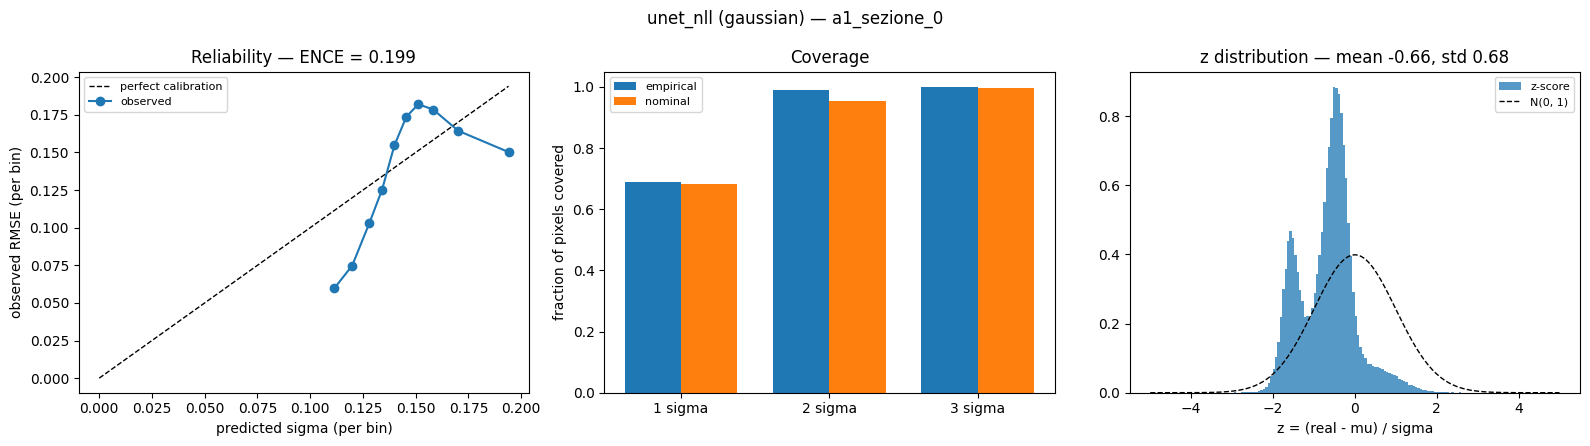

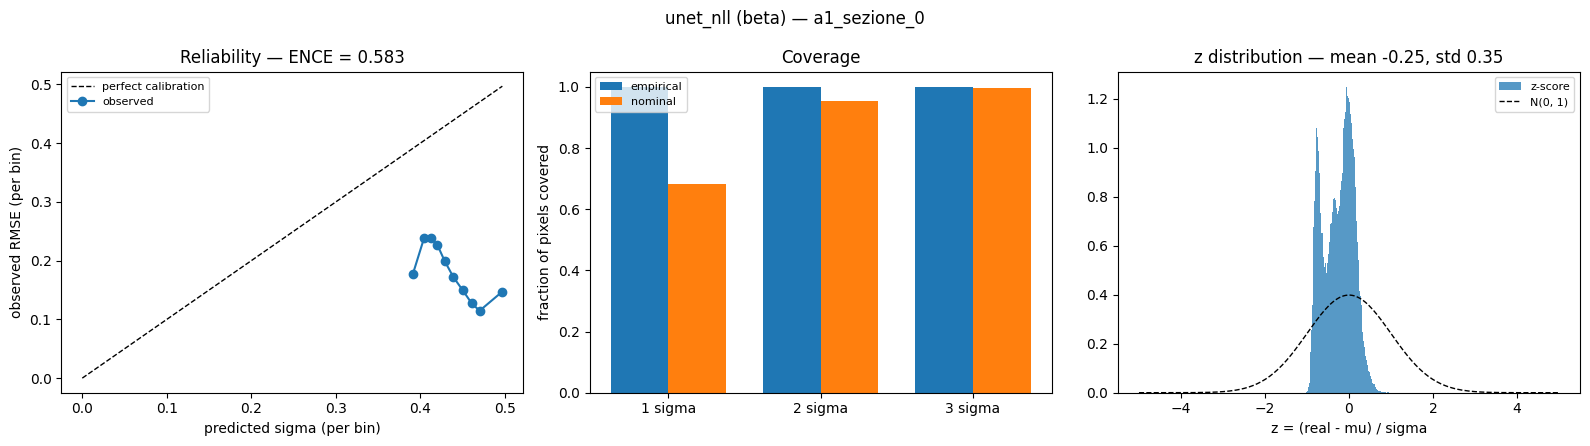

In [11]:
CALIB_DIAGRAM_ARCH = "unet_nll"

for variant in ("gaussian", "beta"):
    key = f"{CALIB_DIAGRAM_ARCH} ({variant})"
    if key not in models:
        print(f"[skip] {key} not loaded")
        continue

    rgb_batch, ir_batch = next(
        iter(build_dataset(calib_pairs[:1], batch_size=1, augment=False, shuffle=False))
    )
    pred = models[key].predict(rgb_batch, verbose=0)[0]
    result = evaluate_calibration(
        ir_batch[0].numpy(), pred[..., 0], np.exp(0.5 * pred[..., 1])
    )
    plot_calibration(result, title=f"{key} — {Path(calib_pairs[0][0]).stem}")
    plt.show()